<a href="https://colab.research.google.com/github/Bismuthe-32/AdaBFs-for-KANs/blob/main/Adaptive_KANs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adaptive Basis Functions in Kolmogorov Arnold Networks

This paper proposes adaptive basis functions (ABFs) for Kolmogorov–Arnold Networks (KANs), enabling dynamic adjustment of univariate basis functions during training. ABF-KANs achieve smoother convergence, improved generalization, and reduced mean-squared error on noisy oscillatory and polynomial functions. Results indicate a 7.6\% reduction in test error relative to fixed-basis KANs. The method addresses limitations of static basis functions, improving scalability, flexibility, and applicability of KANs in complex function approximation tasks.

In [3]:
%pip install ucimlrepo

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
import torch
from torch import nn
from torch.utils.data import Dataset
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo
import torch.nn.functional as F
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def set_seed(seed):
  torch.manual_seed(seed)
  np.random.seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
device = "cuda" if torch.cuda.is_available() else "cpu"

device

'cuda'

We use the following datasets:

- **Synthetic Polynomial Functions:** Functions of the form  

  $$
  f(x) = \sum_{i=0}^{d} p_i x^i + \epsilon
  $$

  where each polynomial coefficient $p_i$ is sampled from a standard Gaussian distribution, and $\epsilon$ represents additive noise. The domain is $x \in [0,10]$, and the output is normalized to the range $[0,1]$.  

- **Boston Housing:** Predicts house prices using 13 input features.  

- **Airfoil Self-Noise:** Predicts sound pressure levels from 5 aerodynamic input variables.  

- **Energy Efficiency:** Predicts heating and cooling loads from 8 building characteristics.  

All datasets are standardized to zero mean and unit variance.


In [5]:
import kagglehub
path = kagglehub.dataset_download("elikplim/eergy-efficiency-dataset")

def generate_synthetic_poly_function(degrees=3, num_points=100, noise_std=0.0):
    X = torch.linspace(0, 1, num_points).unsqueeze(1)
    coeffs = torch.randn(degrees + 1, 1)
    y = sum(coeffs[i] * X ** i for i in range(degrees + 1))
    if noise_std > 0:
        y += torch.randn_like(y) * noise_std
    return X.numpy(), y.numpy()

def load_boston():
    raw_df = fetch_openml(name="Boston", version=1, as_frame=True)
    X = raw_df.data.values
    y = raw_df.target.values.reshape(-1, 1)
    return X, y

def load_airfoil_selfnoise():
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00291/airfoil_self_noise.dat'
    columns = ['frequency', 'angle_of_attack', 'chord_length', 'free_stream_velocity',
               'suction_side_displacement_thickness', 'scaled_sound_pressure_level']
    df = pd.read_csv(url, sep='\t', header=None, names=columns)
    X = df[columns[:-1]].values
    y = df[columns[-1]].values.reshape(-1, 1)
    return X, y

def load_energy_efficiency():
  df=pd.read_csv("/root/.cache/kagglehub/datasets/elikplim/eergy-efficiency-dataset/versions/1/ENB2012_data.csv")
  X=df.drop(["Y1","Y2"],axis=1).values
  y=df['Y1'].values.reshape(-1,1)
  return X, y

100%|██████████| 6.22k/6.22k [00:00<00:00, 1.81MB/s]

Extracting files...


# Model Architectures

We compare Adaptive KANs to three other models:

**Fourier Feature Networks** : Fourier Feature Networks use a Fourier Feature Mapping to transform low-dimensional inputs (like pixel coordinates) into a higher-dimensional space using sines and cosines, allowing standard Multi-Layer Perceptrons (MLPs) to efficiently learn complex, high-frequency functions

**Multilayer Percpetron (MLPs)**: Multi-Layer Perceptrons (MLPs) are fundamental, fully connected feedforward neural networks with input, hidden, and output layers, using non-linear activation functions (like ReLU or sigmoid) to learn complex, non-linear patterns in structured data

**KANs with fixed basis functions** : Kolmogorov-Arnold Networks (KANs) are a novel neural network architecture that replaces fixed node activations in traditional Multi-Layer Perceptrons (MLPs) with learnable, univariate functions (splines) on the network's edges, offering enhanced accuracy, interpretability, and efficiency for complex function approximation

Many thanks to Professor Matthew Johnson at University of Cambridge Department of Engineering for providing the PyTorch Network of Fourier Feature Networks. Full repository on FFNs can be found [here](https://github.com/matajoh/fourier_feature_nets)

In [6]:
from typing import Optional, List

class FourierFeatureMLP(nn.Module):
    """MLP using Fourier features as a preprocessing step."""

    def __init__(self,
                 num_inputs: int,
                 num_outputs: int,
                 a_values: Optional[torch.Tensor],
                 b_values: Optional[torch.Tensor],
                 layer_channels: List[int]):
        super().__init__()
        self.num_inputs = num_inputs

        # Fourier feature encoding
        if b_values is None:
            self.a_values = None
            self.b_values = None
            encoded_inputs = num_inputs
        else:
            assert b_values.shape[0] == num_inputs, "b_values first dim must match num_inputs"
            assert a_values.shape[0] == b_values.shape[1], "a_values shape mismatch"
            self.a_values = nn.Parameter(a_values, requires_grad=False)
            self.b_values = nn.Parameter(b_values, requires_grad=False)
            encoded_inputs = b_values.shape[1] * 2

        # Store params for reproducibility
        self.params = {
            "num_inputs": num_inputs,
            "num_outputs": num_outputs,
            "a_values": None if a_values is None else a_values.tolist(),
            "b_values": None if b_values is None else b_values.tolist(),
            "layer_channels": layer_channels
        }

        # Build MLP layers
        self.layers = nn.ModuleList()
        for num_channels in layer_channels:
            self.layers.append(nn.Linear(encoded_inputs, num_channels))
            encoded_inputs = num_channels
        self.layers.append(nn.Linear(encoded_inputs, num_outputs))

        # Activation tracking
        self.keep_activations = False
        self.activations: List = []

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.b_values is not None:
            encoded = math.pi * x @ self.b_values
            x = torch.cat([self.a_values * encoded.cos(),
                           self.a_values * encoded.sin()], dim=-1)

        self.activations.clear()
        for layer in self.layers[:-1]:
            x = torch.relu(layer(x))
        if self.keep_activations:
            self.activations.append(x.detach().cpu().numpy())
        x = self.layers[-1](x)
        return x

# MLP

We use an MLP with only one hidden layer, and a ReLU activation

In [7]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(SimpleMLP, self).__init__()
        # Define the layers
        self.fc1 = nn.Linear(input_size, hidden_size)  # Fully connected layer 1
        self.fc2 = nn.Linear(hidden_size, output_size) # Fully connected layer 2

    def forward(self, x):
        # Define the forward pass
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

# KAN with fixed basis functions

The network below comprises of a Kolmogorov Arnold network with fixed basis functions. Many thanks to Blealtan for creating the following code snippet. Full repository can be found [here](https://github.com/Blealtan/efficient-kan/tree/master)

### Kolmogorov-Arnold Network (KAN) Architecture

Kolmogorov-Arnold Networks (KANs) are a class of neural networks inspired by the **Kolmogorov-Arnold Representation Theorem**, which states that any continuous multivariate function can be decomposed into a sum of univariate functions composed with addition.

#### Characteristics

- **Basis Functions on Edges:**
  - Instead of scalar weights, each connection between nodes uses a *learnable univariate function* (e.g., spline or radial basis function).
  - This allows each edge to model highly nonlinear transformations.
  
- **No Activations on Nodes:**
  - Nodes simply sum the outputs of incoming basis functions.
  - Nonlinearity comes from the adaptive basis functions themselves.
  
- **Layer Composition:**
  - A KAN layer can be described in matrix form:
$$
    \
    \Phi_{\text{out}} \circ \Phi_{\text{in}}(x)
    \
$$
  where:
  
  - $\Phi_{\text{in}}$ is a matrix of univariate functions applied to each input dimension.
  - $\Phi_{\text{out}}$ sums and composes these outputs.

- **Deep KANs:**
  - Multiple layers are composed to form deeper models, enabling hierarchical function approximation.
$$  
    \
    \text{KAN}(x) = \Phi_1 \circ \Phi_2 \circ \cdots \circ \Phi_L (x)
    \
$$
- **Comparison to MLPs:**
  - In standard MLPs:
    - Linear weights are applied at each layer.
    - Fixed activation functions (e.g., ReLU, tanh) introduce nonlinearity.
  - In KANs:
    - *The weights themselves are learnable functions*, offering richer expressiveness.
    - No explicit activation functions are needed on nodes.

MLPs and KANs follow the same composition structure with layer outputs being passed and inputs into other layers. Given that $W_{L}$ represents layer $L$ and the non linear activation function σ is used through the model.

$$  
    \
    \text{MLP}(x) = (W_{1} \circ σ \circ W_{2} \circ \cdots \circ W_{L}) (x)
    \
$$


#### Benefits of KAN Networks

 - Strong universal approximation capability with fewer nodes per layer

 - Better interpretability of individual basis functions.  

 - Flexible adaptation to complex, nonlinear relationships.

#### Challenges

- More computationally intensive due to function evaluation on each edge.
- Requires careful regularization to avoid overfitting.
- Optimization is more sensitive to initialization and learning dynamics.

KANs are particularly powerful in scenarios where modeling **high-dimensional, highly nonlinear functions** is required.


### Fixed Gaussian RBF Layer

This cell defines the **Fixed Gaussian Radial Basis Function (RBF) Layer** and the **KAN_Fixed model**:

- **`FixedRBF` class:**
  - Implements a set of Gaussian basis functions with *fixed centers and widths*.
  - `num_centers`: number of Gaussian functions.
  - Each Gaussian is defined as:

$$
    \
    \phi_i(x) = \exp\left(-\frac{(x - \mu_i)^2}{2 \sigma_i^2}\right)
    \
$$
  
  - Centers (`μ_i`) are evenly spaced between 0 and 10.
  - Sigmas (`σ_i`) are initialized to 1 and are **not trainable** (`requires_grad=False`).

- **`KAN_Fixed` class:**
  - Composes:
    - The `FixedRBF` layer (computes Gaussian basis function outputs).
    - A `Linear` layer mapping the RBF outputs to a scalar prediction.
  - This model represents a **KAN using static basis functions**, i.e., the Gaussian parameters remain unchanged during training.


In [8]:
import torch
import torch.nn.functional as F
import math


class KANLinear(torch.nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        enable_standalone_scale_spline=True,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        super(KANLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            (
                torch.arange(-spline_order, grid_size + spline_order + 1) * h
                + grid_range[0]
            )
            .expand(in_features, -1)
            .contiguous()
        )
        self.register_buffer("grid", grid)

        self.base_weight = torch.nn.Parameter(torch.Tensor(out_features, in_features))
        self.spline_weight = torch.nn.Parameter(
            torch.Tensor(out_features, in_features, grid_size + spline_order)
        )
        if enable_standalone_scale_spline:
            self.spline_scaler = torch.nn.Parameter(
                torch.Tensor(out_features, in_features)
            )

        self.scale_noise = scale_noise
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.enable_standalone_scale_spline = enable_standalone_scale_spline
        self.base_activation = base_activation()
        self.grid_eps = grid_eps

        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            noise = (
                (
                    torch.rand(self.grid_size + 1, self.in_features, self.out_features)
                    - 1 / 2
                )
                * self.scale_noise
                / self.grid_size
            )
            self.spline_weight.data.copy_(
                (self.scale_spline if not self.enable_standalone_scale_spline else 1.0)
                * self.curve2coeff(
                    self.grid.T[self.spline_order : -self.spline_order],
                    noise,
                )
            )
            if self.enable_standalone_scale_spline:
                # torch.nn.init.constant_(self.spline_scaler, self.scale_spline)
                torch.nn.init.kaiming_uniform_(self.spline_scaler, a=math.sqrt(5) * self.scale_spline)

    def b_splines(self, x: torch.Tensor):
        """
        Compute the B-spline bases for the given input tensor.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).

        Returns:
            torch.Tensor: B-spline bases tensor of shape (batch_size, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features

        grid: torch.Tensor = (
            self.grid
        )  # (in_features, grid_size + 2 * spline_order + 1)
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, : -(k + 1)])
                / (grid[:, k:-1] - grid[:, : -(k + 1)])
                * bases[:, :, :-1]
            ) + (
                (grid[:, k + 1 :] - x)
                / (grid[:, k + 1 :] - grid[:, 1:(-k)])
                * bases[:, :, 1:]
            )

        assert bases.size() == (
            x.size(0),
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return bases.contiguous()

    def curve2coeff(self, x: torch.Tensor, y: torch.Tensor):
        """
        Compute the coefficients of the curve that interpolates the given points.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).
            y (torch.Tensor): Output tensor of shape (batch_size, in_features, out_features).

        Returns:
            torch.Tensor: Coefficients tensor of shape (out_features, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features
        assert y.size() == (x.size(0), self.in_features, self.out_features)

        A = self.b_splines(x).transpose(
            0, 1
        )  # (in_features, batch_size, grid_size + spline_order)
        B = y.transpose(0, 1)  # (in_features, batch_size, out_features)
        solution = torch.linalg.lstsq(
            A, B
        ).solution  # (in_features, grid_size + spline_order, out_features)
        result = solution.permute(
            2, 0, 1
        )  # (out_features, in_features, grid_size + spline_order)

        assert result.size() == (
            self.out_features,
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return result.contiguous()

    @property
    def scaled_spline_weight(self):
        return self.spline_weight * (
            self.spline_scaler.unsqueeze(-1)
            if self.enable_standalone_scale_spline
            else 1.0
        )

    def forward(self, x: torch.Tensor):
        assert x.size(-1) == self.in_features
        original_shape = x.shape
        x = x.reshape(-1, self.in_features)

        base_output = F.linear(self.base_activation(x), self.base_weight)
        spline_output = F.linear(
            self.b_splines(x).view(x.size(0), -1),
            self.scaled_spline_weight.view(self.out_features, -1),
        )
        output = base_output + spline_output

        output = output.reshape(*original_shape[:-1], self.out_features)
        return output

    @torch.no_grad()
    def update_grid(self, x: torch.Tensor, margin=0.01):
        assert x.dim() == 2 and x.size(1) == self.in_features
        batch = x.size(0)

        splines = self.b_splines(x)  # (batch, in, coeff)
        splines = splines.permute(1, 0, 2)  # (in, batch, coeff)
        orig_coeff = self.scaled_spline_weight  # (out, in, coeff)
        orig_coeff = orig_coeff.permute(1, 2, 0)  # (in, coeff, out)
        unreduced_spline_output = torch.bmm(splines, orig_coeff)  # (in, batch, out)
        unreduced_spline_output = unreduced_spline_output.permute(
            1, 0, 2
        )  # (batch, in, out)

        # sort each channel individually to collect data distribution
        x_sorted = torch.sort(x, dim=0)[0]
        grid_adaptive = x_sorted[
            torch.linspace(
                0, batch - 1, self.grid_size + 1, dtype=torch.int64, device=x.device
            )
        ]

        uniform_step = (x_sorted[-1] - x_sorted[0] + 2 * margin) / self.grid_size
        grid_uniform = (
            torch.arange(
                self.grid_size + 1, dtype=torch.float32, device=x.device
            ).unsqueeze(1)
            * uniform_step
            + x_sorted[0]
            - margin
        )

        grid = self.grid_eps * grid_uniform + (1 - self.grid_eps) * grid_adaptive
        grid = torch.concatenate(
            [
                grid[:1]
                - uniform_step
                * torch.arange(self.spline_order, 0, -1, device=x.device).unsqueeze(1),
                grid,
                grid[-1:]
                + uniform_step
                * torch.arange(1, self.spline_order + 1, device=x.device).unsqueeze(1),
            ],
            dim=0,
        )

        self.grid.copy_(grid.T)
        self.spline_weight.data.copy_(self.curve2coeff(x, unreduced_spline_output))

    def regularization_loss(self, regularize_activation=1.0, regularize_entropy=1.0):
        """
        Compute the regularization loss.

        This is a dumb simulation of the original L1 regularization as stated in the
        paper, since the original one requires computing absolutes and entropy from the
        expanded (batch, in_features, out_features) intermediate tensor, which is hidden
        behind the F.linear function if we want an memory efficient implementation.

        The L1 regularization is now computed as mean absolute value of the spline
        weights. The authors implementation also includes this term in addition to the
        sample-based regularization.
        """
        l1_fake = self.spline_weight.abs().mean(-1)
        regularization_loss_activation = l1_fake.sum()
        p = l1_fake / regularization_loss_activation
        regularization_loss_entropy = -torch.sum(p * p.log())
        return (
            regularize_activation * regularization_loss_activation
            + regularize_entropy * regularization_loss_entropy
        )


class KAN(torch.nn.Module):
    def __init__(
        self,
        layers_hidden,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        super(KAN, self).__init__()
        self.grid_size = grid_size
        self.spline_order = spline_order

        self.layers = torch.nn.ModuleList()
        for in_features, out_features in zip(layers_hidden, layers_hidden[1:]):
            self.layers.append(
                KANLinear(
                    in_features,
                    out_features,
                    grid_size=grid_size,
                    spline_order=spline_order,
                    scale_noise=scale_noise,
                    scale_base=scale_base,
                    scale_spline=scale_spline,
                    base_activation=base_activation,
                    grid_eps=grid_eps,
                    grid_range=grid_range,
                )
            )

    def forward(self, x: torch.Tensor, update_grid=False):
        for layer in self.layers:
            if update_grid:
                layer.update_grid(x)
            x = layer(x)
        return x

    def regularization_loss(self, regularize_activation=1.0, regularize_entropy=1.0):
        return sum(
            layer.regularization_loss(regularize_activation, regularize_entropy)
            for layer in self.layers
        )

### Adaptive Gaussian RBF Layer

This cell defines the **Adaptive Gaussian Radial Basis Function (RBF) Layer** and the **KAN_Adaptive model**:

- **`AdaptiveRBF` class:**
  - Implements a set of Gaussian basis functions where **both centers and sigmas are trainable**.
  - `num_centers`: number of Gaussian functions.
  - Each Gaussian is defined as:
$$
    \
    \phi_i(x) = \exp\left(-\frac{(x - \mu_i)^2}{2 \sigma_i^2}\right)
    \
$$
  - Unlike the fixed version:
    - `centers` (`μ_i`) are initialized evenly between 0 and 10 but are **learned during training** (`requires_grad=True`).
    - `sigmas` (`σ_i`) are also **learned**, enabling the network to adapt the shape and location of each basis function dynamically.

- **`KAN_Adaptive` class:**
  - Composes:
    - The `AdaptiveRBF` layer (outputs adaptive Gaussian basis activations).
    - A `Linear` layer mapping these activations to a scalar prediction.
  - This model represents a **KAN using adaptive basis functions**, allowing it to better capture complex, nonlinear patterns in data.


In [9]:
class AdaptiveKAN(KAN):
    """
    KAN with adaptive basis functions.
    Automatically updates the spline grid based on input distribution
    at each forward pass if `update_grid=True`.
    """

    def __init__(
        self,
        layers_hidden,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
        update_grid_every_forward=True,  # controls auto adaptation
    ):
        super().__init__(
            layers_hidden,
            grid_size=grid_size,
            spline_order=spline_order,
            scale_noise=scale_noise,
            scale_base=scale_base,
            scale_spline=scale_spline,
            base_activation=base_activation,
            grid_eps=grid_eps,
            grid_range=grid_range,
        )
        self.update_grid_every_forward = update_grid_every_forward

    def forward(self, x: torch.Tensor, update_grid=False):
        # If adaptive updating is enabled globally
        adaptive_update = self.update_grid_every_forward or update_grid
        for layer in self.layers:
            if adaptive_update:
                layer.update_grid(x)
            x = layer(x)
        return x


In [10]:
def load_fourier(dataset_x: np.ndarray, dataset_y: np.ndarray) -> FourierFeatureMLP:
    input_dim = dataset_x.shape[1]
    output_dim = dataset_y.shape[1]

    num_fourier_features = 16

    # Correct shapes
    a_values = torch.ones(num_fourier_features)             # shape: [num_features]
    b_values = torch.randn(input_dim, num_fourier_features) # shape: [input_dim, num_features]

    fourier_model = FourierFeatureMLP(
        num_inputs=input_dim,
        num_outputs=output_dim,
        a_values=a_values,
        b_values=b_values,
        layer_channels=[64, 64]
    )

    return fourier_model

def load_mlp(dataset_x: np.ndarray, dataset_y: np.ndarray) -> SimpleMLP:
    input_dim = dataset_x.shape[1]
    output_dim = dataset_y.shape[1]

    mlp_model = SimpleMLP(input_dim, 10, output_dim)

    return mlp_model

def load_kan(
    dataset_x: np.ndarray,
    dataset_y: np.ndarray,
    layers_hidden: list = None,
    grid_size: int = 5,
    spline_order: int = 3,
    scale_noise: float = 0.1,
    scale_base: float = 1.0,
    scale_spline: float = 1.0,
    base_activation=torch.nn.SiLU,
    grid_eps: float = 0.02,
    grid_range: list = [-1, 1],
) -> KAN:
    """
    Initialize a KAN model for the given dataset.

    Args:
        dataset_x (np.ndarray): Input data (N x input_dim)
        dataset_y (np.ndarray): Output data (N x output_dim)
        layers_hidden (list): List of hidden layer sizes, including input/output dims
        Other args: Passed directly to KAN constructor

    Returns:
        model (KAN): Initialized KAN model
    """
    input_dim = dataset_x.shape[1]
    output_dim = dataset_y.shape[1]

    # Default hidden layers if not provided
    if layers_hidden is None:
        layers_hidden = [input_dim, 64, 64, output_dim]
    else:
        # Ensure input/output are included
        layers_hidden = [input_dim] + layers_hidden + [output_dim]

    # Create KAN model
    model = KAN(
        layers_hidden=layers_hidden,
        grid_size=grid_size,
        spline_order=spline_order,
        scale_noise=scale_noise,
        scale_base=scale_base,
        scale_spline=scale_spline,
        base_activation=base_activation,
        grid_eps=grid_eps,
        grid_range=grid_range,
    )

    return model

def load_adaptive_kan(
    dataset_x: np.ndarray,
    dataset_y: np.ndarray,
    layers_hidden: list = None,
    grid_size: int = 5,
    spline_order: int = 3,
    scale_noise: float = 0.1,
    scale_base: float = 1.0,
    scale_spline: float = 1.0,
    base_activation=torch.nn.SiLU,
    grid_eps: float = 0.02,
    grid_range: list = [-1, 1],
    update_grid_every_forward: bool = True
) -> AdaptiveKAN:
    """
    Initialize an AdaptiveKAN model for the given dataset.

    Args:
        dataset_x (np.ndarray): Input data (N x input_dim)
        dataset_y (np.ndarray): Output data (N x output_dim)
        layers_hidden (list): List of hidden layer sizes (excluding input/output)
        update_grid_every_forward (bool): If True, adapt spline grids at each forward pass
        Other args: Passed directly to AdaptiveKAN constructor

    Returns:
        model (AdaptiveKAN): Initialized AdaptiveKAN model
    """
    input_dim = dataset_x.shape[1]
    output_dim = dataset_y.shape[1]

    # Default hidden layers if not provided
    if layers_hidden is None:
        layers_hidden = [input_dim, 64, 64, output_dim]
    else:
        # Ensure input/output are included
        layers_hidden = [input_dim] + layers_hidden + [output_dim]

    # Create AdaptiveKAN model
    model = AdaptiveKAN(
        layers_hidden=layers_hidden,
        grid_size=grid_size,
        spline_order=spline_order,
        scale_noise=scale_noise,
        scale_base=scale_base,
        scale_spline=scale_spline,
        base_activation=base_activation,
        grid_eps=grid_eps,
        grid_range=grid_range,
        update_grid_every_forward=update_grid_every_forward
    )

    return model


In [11]:
import torch
from typing import List, Optional

def train_model_unified(
    dataset_x: np.ndarray,
    dataset_y: np.ndarray,
    model_type: str = "adaptive_kan",   # 'fourier', 'kan', 'adaptive_kan', 'mlp'
    hidden_layers: Optional[List[int]] = None,
    fourier_features: int = 16,
    loss_fn=torch.nn.MSELoss,
    optimizer_fn=torch.optim.Adam,
    lr: float = 0.01,
    epochs: int = 50,
    batch_size: int = 64,
    device=None
):
    loss_list=[]
    """
    Robust unified training function for FourierFeatureMLP, KAN, AdaptiveKAN, or plain MLP.
    Supports mini-batching to prevent AdaptiveKAN least-squares errors.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    x_tensor = torch.tensor(dataset_x, dtype=torch.float32, device=device)
    y_tensor = torch.tensor(dataset_y, dtype=torch.float32, device=device)

    input_dim = dataset_x.shape[1]
    output_dim = dataset_y.shape[1]

    if hidden_layers is None:
        hidden_layers = [64, 64]

    # --- Model instantiation ---
    if model_type.lower() == "fourier":
        a_values = torch.ones(fourier_features)
        b_values = torch.randn(input_dim, fourier_features)
        model = FourierFeatureMLP(input_dim, output_dim, a_values, b_values, hidden_layers).to(device)

    elif model_type.lower() == "kan":
        layers_hidden = [input_dim] + hidden_layers + [output_dim]
        model = KAN(layers_hidden).to(device)

    elif model_type.lower() == "adaptive_kan":
        layers_hidden = [input_dim] + hidden_layers + [output_dim]

        # Disable adaptive update if batch too small or input_dim is 1
        adaptive_flag = False
        if input_dim <= 1 or x_tensor.shape[0] < 8:  # heuristic thresholds
            adaptive_flag = False

        model = AdaptiveKAN(layers_hidden, update_grid_every_forward=adaptive_flag).to(device)

    elif model_type.lower() == "mlp":
      model = load_mlp(dataset_x, dataset_y).to(device)

    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    # --- Loss and optimizer ---
    criterion = loss_fn()
    optimizer = optimizer_fn(model.parameters(), lr=lr)

    # --- Training loop with mini-batches ---
    num_samples = x_tensor.shape[0]
    model.train()
    for epoch in range(epochs):
        perm = torch.randperm(num_samples)
        epoch_loss = 0.0

        for i in range(0, num_samples, batch_size):
            idx = perm[i:i+batch_size]
            x_batch = x_tensor[idx]
            y_batch = y_tensor[idx]

            # Small jitter to prevent exact duplicates for AdaptiveKAN
            if model_type.lower() == "adaptive_kan":
                x_batch = x_batch + 1e-6 * torch.randn_like(x_batch)

            optimizer.zero_grad()
            y_hat = model(x_batch)
            loss = criterion(y_hat, y_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * x_batch.shape[0]

        avg_loss = epoch_loss / num_samples
        loss_list.append(avg_loss)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"[{model_type}] Epoch {epoch+1}/{epochs} | Avg Loss: {avg_loss:.6f}")

    return model, loss_list


In [12]:
import torch
import numpy as np
from typing import Tuple

def test_model_unified(
    model: torch.nn.Module,
    dataset_x: np.ndarray,
    dataset_y: np.ndarray,
    loss_fn=torch.nn.MSELoss,
    device=None,
    return_predictions: bool = False
) -> Tuple[float, torch.Tensor]:
    """
    Unified evaluation function for trained models.
    Returns average loss and optionally predictions.
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    x_tensor = torch.tensor(dataset_x, dtype=torch.float32, device=device)
    y_tensor = torch.tensor(dataset_y, dtype=torch.float32, device=device)

    criterion = loss_fn()

    model.eval()
    with torch.no_grad():
        y_hat = model(x_tensor)
        loss = criterion(y_hat, y_tensor).item()

    if return_predictions:
        return loss, y_hat.cpu()
    else:
        return loss


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from collections import defaultdict

datasets = {
    "synthetic_poly": generate_synthetic_poly_function,
    "boston": load_boston,
    "airfoil": load_airfoil_selfnoise,
    "energy": load_energy_efficiency
}

loss_per_model = {}
models = ["fourier", "kan", "adaptive_kan", "mlp"]

NUM_SEEDS = 20
SEEDS = list(range(NUM_SEEDS))

results = {}  # results[dataset][model] = list of test losses

for dataset_name, dataset_func in datasets.items():
    results[dataset_name] = {}

    X, y = dataset_func()
    if dataset_name != "synthetic_poly":
        X = StandardScaler().fit_transform(X)
        y = StandardScaler().fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    for model_type in models:
        losses = []
        for seed in SEEDS:
            set_seed(seed)

            model, _ = train_model_unified(
                X_train, y_train,
                model_type=model_type,
                hidden_layers=[64, 64],
                epochs=30,
                lr=0.01,
                device=device
            )

            test_loss = test_model_unified(model, X_test, y_test, device=device)
            losses.append(test_loss)

        results[dataset_name][model_type] = np.array(losses)

[fourier] Epoch 1/30 | Avg Loss: 7.313312
[fourier] Epoch 10/30 | Avg Loss: 0.338859
[fourier] Epoch 20/30 | Avg Loss: 0.031249
[fourier] Epoch 30/30 | Avg Loss: 0.003822
[fourier] Epoch 1/30 | Avg Loss: 7.964314
[fourier] Epoch 10/30 | Avg Loss: 0.102888
[fourier] Epoch 20/30 | Avg Loss: 0.032129
[fourier] Epoch 30/30 | Avg Loss: 0.008620
[fourier] Epoch 1/30 | Avg Loss: 7.480949
[fourier] Epoch 10/30 | Avg Loss: 0.225883
[fourier] Epoch 20/30 | Avg Loss: 0.024227
[fourier] Epoch 30/30 | Avg Loss: 0.003300
[fourier] Epoch 1/30 | Avg Loss: 8.013192
[fourier] Epoch 10/30 | Avg Loss: 0.090933
[fourier] Epoch 20/30 | Avg Loss: 0.025893
[fourier] Epoch 30/30 | Avg Loss: 0.003546
[fourier] Epoch 1/30 | Avg Loss: 7.471817
[fourier] Epoch 10/30 | Avg Loss: 0.239808
[fourier] Epoch 20/30 | Avg Loss: 0.021860
[fourier] Epoch 30/30 | Avg Loss: 0.002605
[fourier] Epoch 1/30 | Avg Loss: 7.203478
[fourier] Epoch 10/30 | Avg Loss: 0.126259
[fourier] Epoch 20/30 | Avg Loss: 0.011162
[fourier] Epoch 3

In [14]:
from scipy.stats import friedmanchisquare

for dataset_name, model_results in results.items():
    data = [model_results[m] for m in models]
    stat, p = friedmanchisquare(*data)
    print(f"{dataset_name} | Friedman χ²={stat:.3f}, p={p:.3e}")

synthetic_poly | Friedman χ²=37.680, p=3.304e-08
boston | Friedman χ²=54.540, p=8.607e-12
airfoil | Friedman χ²=54.960, p=7.002e-12
energy | Friedman χ²=54.060, p=1.089e-11


In [15]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

def pairwise_tests(results, ref="adaptive_kan"):
    pvals = []
    comparisons = []

    for model in models:
        if model == ref:
            continue
        stat, p = wilcoxon(results[ref], results[model])
        pvals.append(p)
        comparisons.append((ref, model))

    corrected = multipletests(pvals, method="holm")

    for (a, b), p_raw, p_corr, reject in zip(comparisons, pvals, corrected[1], corrected[0]):
        print(f"{a} vs {b} | p={p_raw:.3e}, p_corr={p_corr:.3e}, reject={reject}")


In [16]:
delta_dict = {}

def cliffs_delta(x, y):
    nx, ny = len(x), len(y)
    greater = sum(i > j for i in x for j in y)
    less = sum(i < j for i in x for j in y)
    return (greater - less) / (nx * ny)

for dataset_name, model_results in results.items():
    delta_dict[dataset_name] = {}
    ref = model_results["adaptive_kan"]
    for model in models:
        if model == "adaptive_kan":
            continue
        delta = cliffs_delta(ref, model_results[model])
        comparison_name = f"AdaptiveKAN vs {model}"
        delta_dict[dataset_name][comparison_name] = delta
        print(f"{dataset_name} | {comparison_name} | Cliff’s δ = {delta:.3f}")

synthetic_poly | AdaptiveKAN vs fourier | Cliff’s δ = 0.230
synthetic_poly | AdaptiveKAN vs kan | Cliff’s δ = -0.005
synthetic_poly | AdaptiveKAN vs mlp | Cliff’s δ = -1.000
boston | AdaptiveKAN vs fourier | Cliff’s δ = -1.000
boston | AdaptiveKAN vs kan | Cliff’s δ = 0.015
boston | AdaptiveKAN vs mlp | Cliff’s δ = -1.000
airfoil | AdaptiveKAN vs fourier | Cliff’s δ = -1.000
airfoil | AdaptiveKAN vs kan | Cliff’s δ = 0.020
airfoil | AdaptiveKAN vs mlp | Cliff’s δ = -1.000
energy | AdaptiveKAN vs fourier | Cliff’s δ = -1.000
energy | AdaptiveKAN vs kan | Cliff’s δ = -0.005
energy | AdaptiveKAN vs mlp | Cliff’s δ = -1.000


In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_boxplots(results, dataset_name, file_name):
    models = list(results[dataset_name].keys())
    data = [results[dataset_name][m] for m in models]

    plt.figure()
    plt.boxplot(data, labels=models, showfliers=True)
    plt.ylabel("Test MSE")
    plt.title(f"Performance Distribution — {dataset_name}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    plt.savefig(file_name)


In [18]:
def plot_mean_ci(results, dataset_name, file_name):
    models = list(results[dataset_name].keys())

    means = []
    cis = []

    for m in models:
        vals = np.array(results[dataset_name][m])
        mean = vals.mean()
        ci = 1.96 * vals.std(ddof=1) / np.sqrt(len(vals))
        means.append(mean)
        cis.append(ci)

    x = np.arange(len(models))

    plt.figure()
    plt.errorbar(x, means, yerr=cis, fmt='o', capsize=5)
    plt.xticks(x, models, rotation=20)
    plt.ylabel("Test MSE")
    plt.title(f"Mean ± 95% CI — {dataset_name}")
    plt.tight_layout()
    plt.show()

    plt.savefig(file_name)


In [19]:
from scipy.stats import rankdata

def plot_rank_distributions(results, dataset_name, file_name):
    models = list(results[dataset_name].keys())
    num_seeds = len(results[dataset_name][models[0]])

    ranks = {m: [] for m in models}

    for seed in range(num_seeds):
        losses = [results[dataset_name][m][seed] for m in models]
        seed_ranks = rankdata(losses)  # lower loss = better rank

        for m, r in zip(models, seed_ranks):
            ranks[m].append(r)

    plt.figure()
    plt.boxplot([ranks[m] for m in models], labels=models)
    plt.ylabel("Rank (lower = better)")
    plt.title(f"Rank Distributions — {dataset_name}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    plt.savefig(file_name)


In [20]:
def plot_training_curves(train_curves, dataset_name, file_name):
    """
    Plots training loss curves for all models in a single figure and saves the figure.

    train_curves[dataset_name][model] = list of training losses per epoch
    """
    curves_per_model = train_curves[dataset_name]

    plt.figure(figsize=(6,4))

    for model_name, curves in curves_per_model.items():
        plt.plot(curves, label=model_name)

    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title(f"Training Loss per Model — {dataset_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(file_name)   # Save figure first
    plt.show()               # Then show it

In [21]:
def plot_cliffs_delta(delta_dict, dataset_name, file_name):
    """
    delta_dict format:
    delta_dict[dataset][comparison] = delta
    """
    comps = list(delta_dict[dataset_name].keys())
    deltas = [delta_dict[dataset_name][c] for c in comps]

    plt.figure()
    plt.bar(comps, deltas)
    plt.axhline(0)
    plt.ylabel("Cliff's δ")
    plt.title(f"Effect Sizes — {dataset_name}")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    plt.savefig(file_name)


In [22]:
results

{'synthetic_poly': {'fourier': array([0.00577132, 0.00211238, 0.00344903, 0.00279234, 0.00072744,
         0.00130857, 0.00444844, 0.00284362, 0.00565293, 0.0045398 ,
         0.0060493 , 0.00053379, 0.00100007, 0.00919138, 0.00296555,
         0.0032883 , 0.0020114 , 0.00125694, 0.0016551 , 0.00226148]),
  'kan': array([0.00165964, 0.0063456 , 0.00363126, 0.00092984, 0.00175259,
         0.003733  , 0.00099477, 0.00449204, 0.0035671 , 0.00319011,
         0.0041571 , 0.00235246, 0.00641469, 0.00372155, 0.00364439,
         0.00404652, 0.00352053, 0.00209386, 0.00577547, 0.00622206]),
  'adaptive_kan': array([0.00165959, 0.0063455 , 0.00363123, 0.00092983, 0.00175262,
         0.00373292, 0.0009948 , 0.0044921 , 0.00356714, 0.00319006,
         0.00415709, 0.00235245, 0.00641472, 0.00372148, 0.00364441,
         0.00404655, 0.00352052, 0.00209393, 0.0057754 , 0.00622208]),
  'mlp': array([0.04209999, 0.05156242, 0.13430652, 0.1658334 , 0.15681815,
         0.25026199, 0.11212444, 1.505

/tmp/ipython-input-1435247982.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=models, showfliers=True)


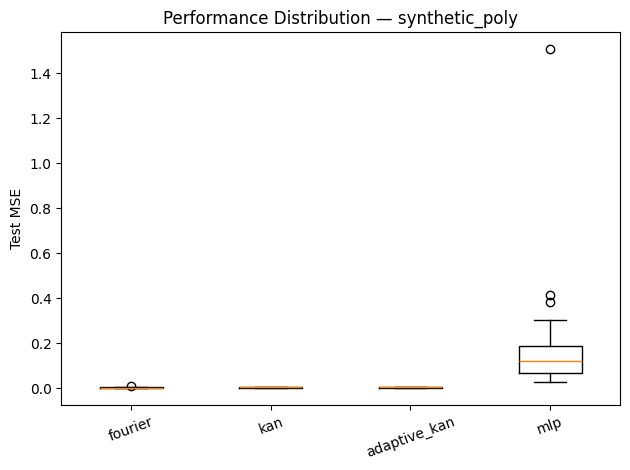

<Figure size 640x480 with 0 Axes>

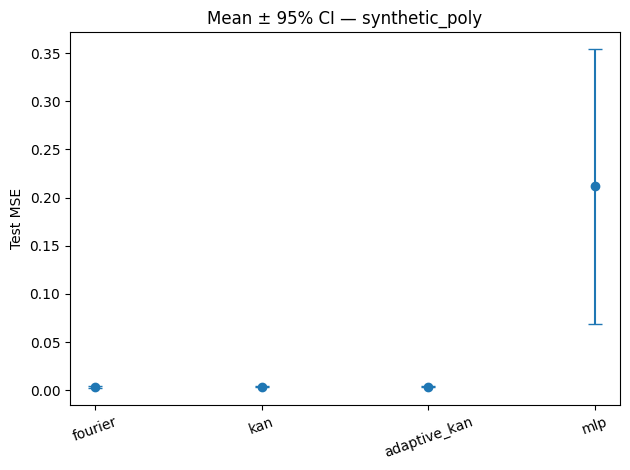

/tmp/ipython-input-2150761983.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ranks[m] for m in models], labels=models)


<Figure size 640x480 with 0 Axes>

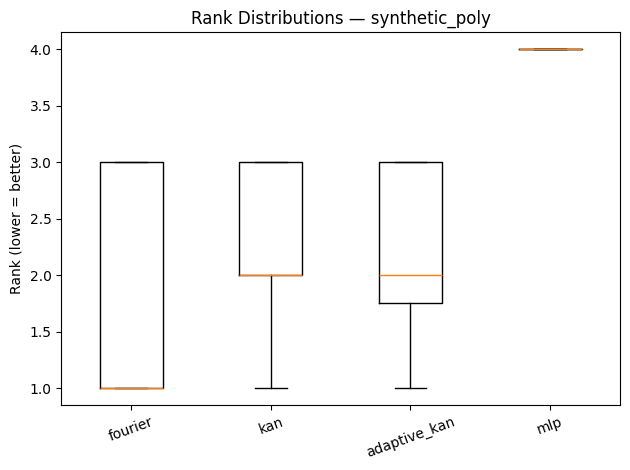

<Figure size 640x480 with 0 Axes>

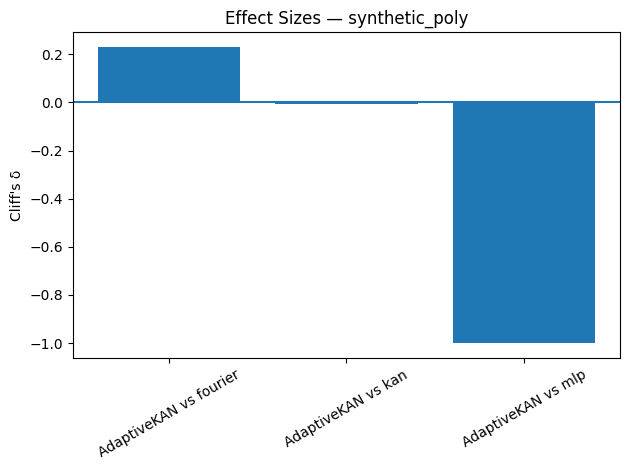

<Figure size 640x480 with 0 Axes>

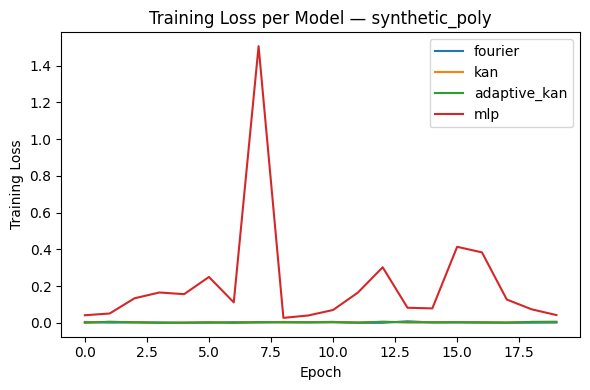

/tmp/ipython-input-1435247982.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=models, showfliers=True)


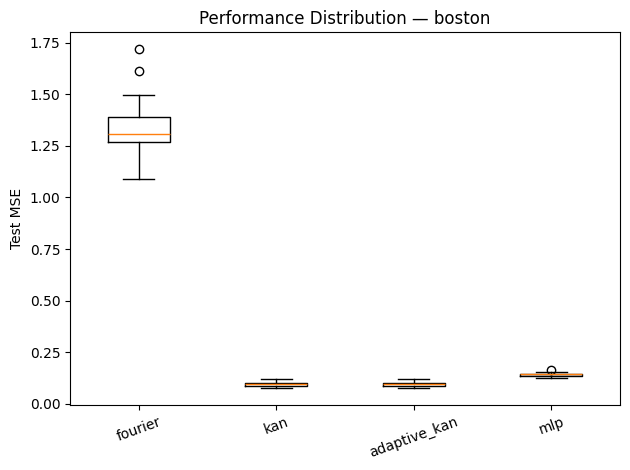

<Figure size 640x480 with 0 Axes>

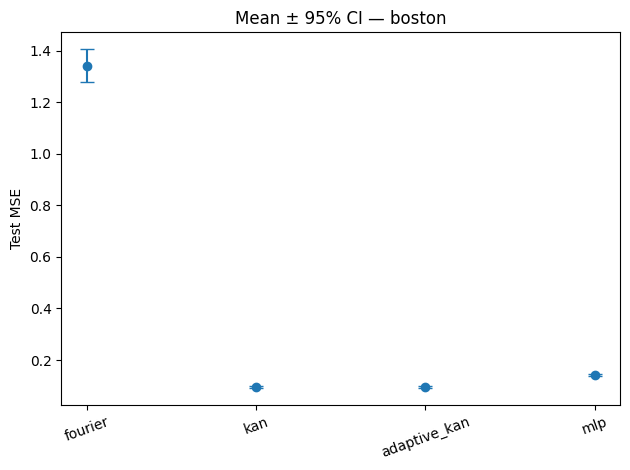

/tmp/ipython-input-2150761983.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ranks[m] for m in models], labels=models)


<Figure size 640x480 with 0 Axes>

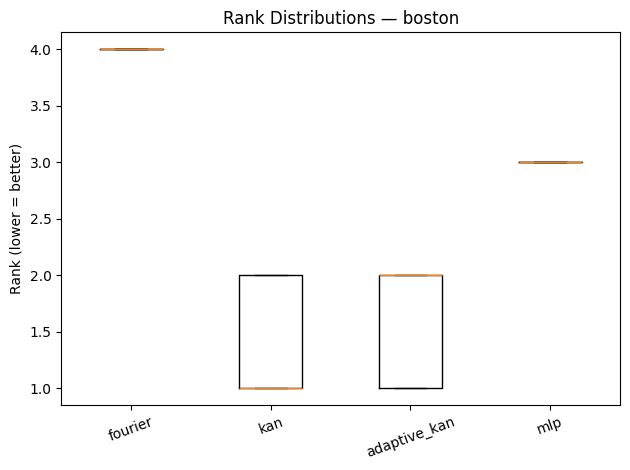

<Figure size 640x480 with 0 Axes>

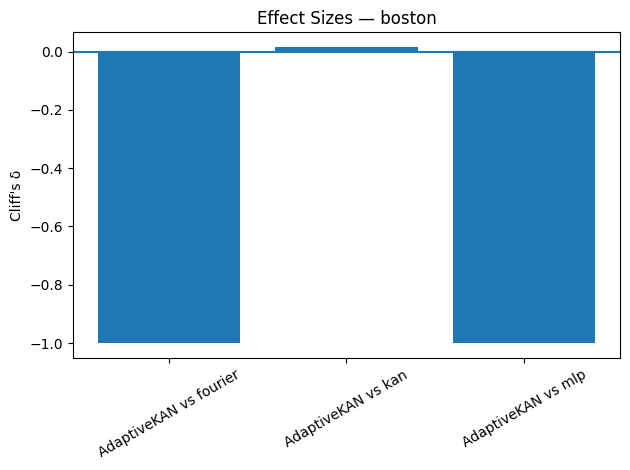

<Figure size 640x480 with 0 Axes>

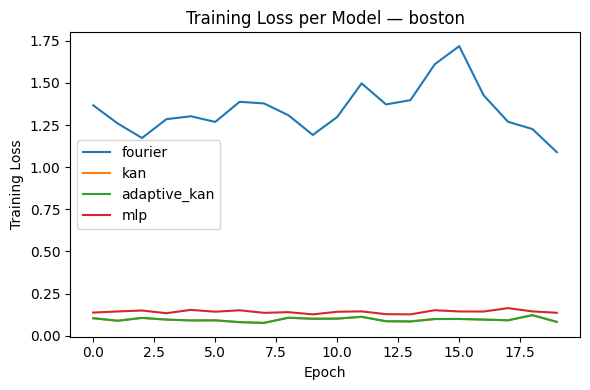

/tmp/ipython-input-1435247982.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=models, showfliers=True)


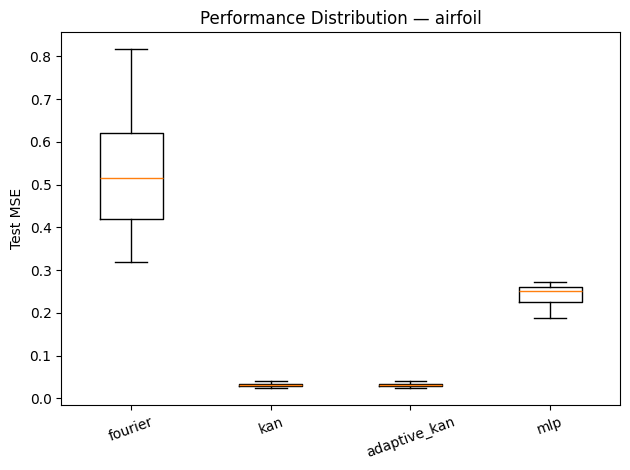

<Figure size 640x480 with 0 Axes>

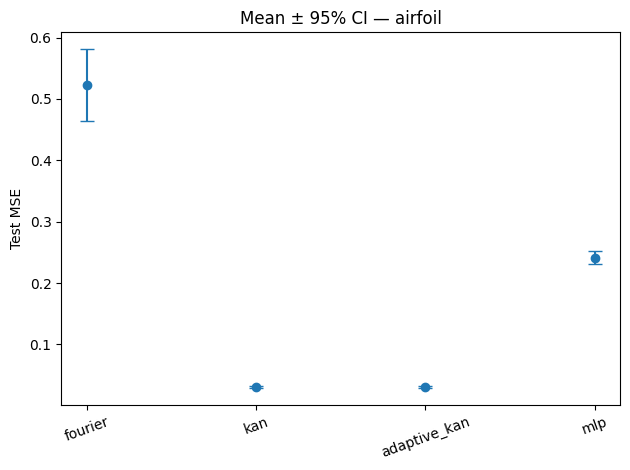

/tmp/ipython-input-2150761983.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ranks[m] for m in models], labels=models)


<Figure size 640x480 with 0 Axes>

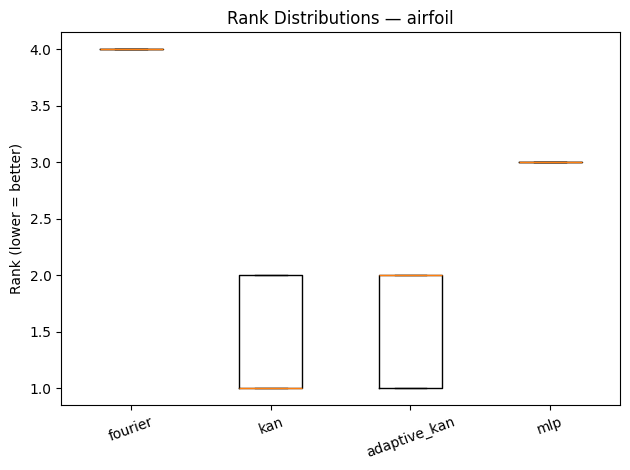

<Figure size 640x480 with 0 Axes>

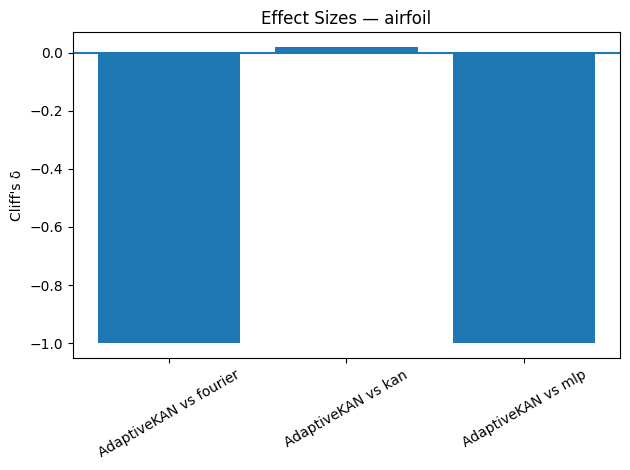

<Figure size 640x480 with 0 Axes>

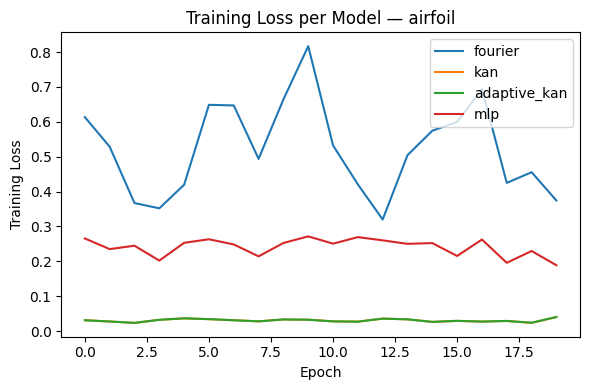

/tmp/ipython-input-1435247982.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=models, showfliers=True)


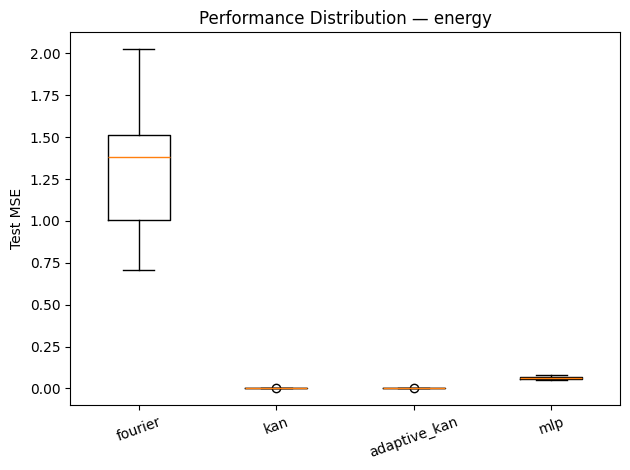

<Figure size 640x480 with 0 Axes>

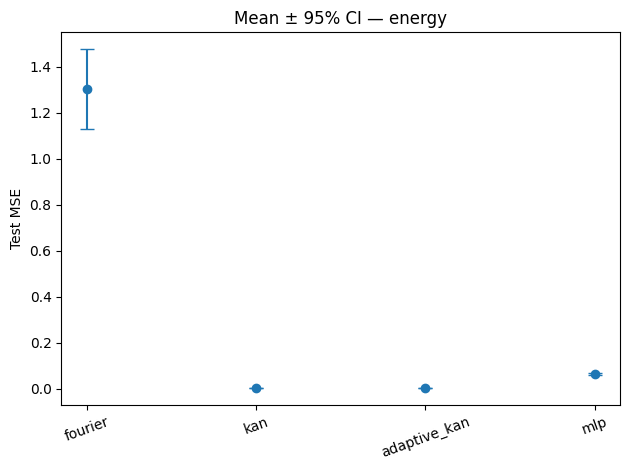

/tmp/ipython-input-2150761983.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ranks[m] for m in models], labels=models)


<Figure size 640x480 with 0 Axes>

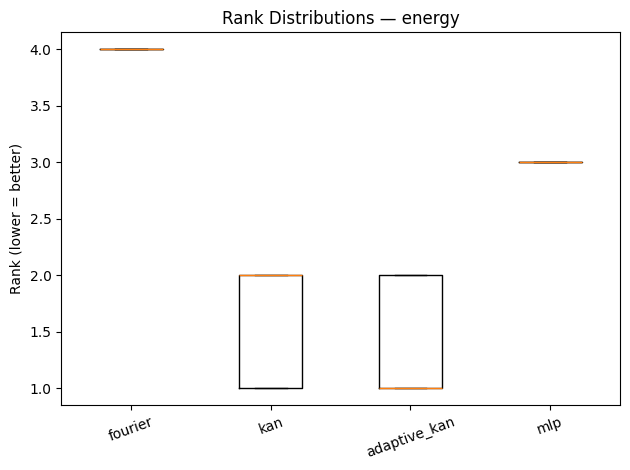

<Figure size 640x480 with 0 Axes>

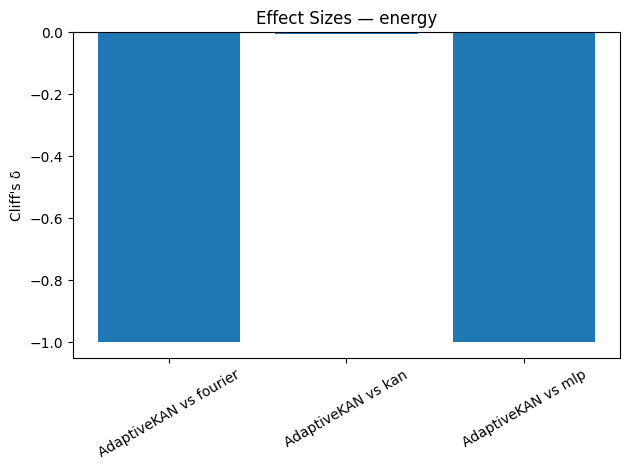

<Figure size 640x480 with 0 Axes>

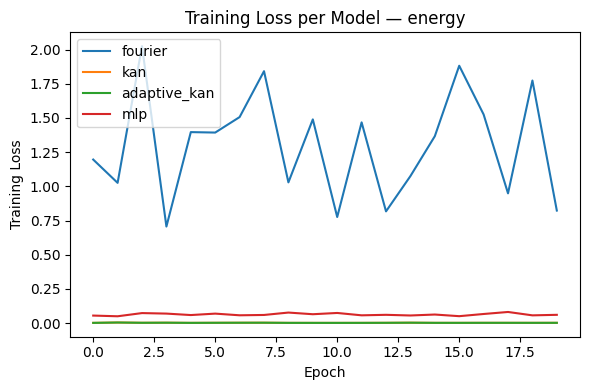

In [24]:
for dataset_name, model_results in results.items():
  plot_boxplots(results, dataset_name, f"/content/drive/MyDrive/AdaBF: Creating your own building blocks/results/{dataset_name}-box-plot.png")
  plot_mean_ci(results, dataset_name, f"/content/drive/MyDrive/AdaBF: Creating your own building blocks/results/{dataset_name}-mean-ci.png")
  plot_rank_distributions(results, dataset_name, f"/content/drive/MyDrive/AdaBF: Creating your own building blocks/results/{dataset_name}-rk-dist.png")
  plot_cliffs_delta(delta_dict, dataset_name, f"/content/drive/MyDrive/AdaBF: Creating your own building blocks/results/{dataset_name}-cliff-d.png")
  plot_training_curves(results, dataset_name, f"/content/drive/MyDrive/AdaBF: Creating your own building blocks/results/{dataset_name}-training-curve.png")